In [1]:
!pip install pillow

In [2]:
from google.colab import files

uploaded = files.upload()

Saving bunga.bmp to bunga.bmp
Saving secret.txt to secret.txt


In [3]:
from PIL import Image
from google.colab import files
from IPython.display import display

def text_to_binary(text):
    return ''.join(format(ord(char), '08b') for char in text)

def binary_to_text(binary):
    chars = [binary[i:i+8] for i in range(0, len(binary), 8)]
    return ''.join(chr(int(char, 2)) for char in chars)

def encode_image(image_path, secret_text_path, output_path):
    image = Image.open(image_path)
    image = image.convert('RGB')
    pixels = list(image.getdata())

    # Membaca isi file rahasia
    with open(secret_text_path, 'r', encoding='utf-8') as file:
        secret_text = file.read()

    secret_text += "###END###"

    binary_secret = text_to_binary(secret_text)
    binary_index = 0

    new_pixels = []

    for pixel in pixels:
        r, g, b = pixel

        if binary_index < len(binary_secret):
            r = (r & ~1) | int(binary_secret[binary_index])
            binary_index += 1

        if binary_index < len(binary_secret):
            g = (g & ~1) | int(binary_secret[binary_index])
            binary_index += 1

        if binary_index < len(binary_secret):
            b = (b & ~1) | int(binary_secret[binary_index])
            binary_index += 1

        new_pixels.append((r, g, b))

    if binary_index < len(binary_secret):
        raise ValueError("Pesan terlalu besar untuk gambar ini!")

    encoded_image = Image.new(image.mode, image.size)
    encoded_image.putdata(new_pixels)
    encoded_image.save(output_path)

    print(f"Pesan berhasil disisipkan ke dalam gambar: {output_path}")

def decode_image(image_path):
    image = Image.open(image_path)
    image = image.convert('RGB')
    pixels = list(image.getdata())

    binary_data = ""

    for pixel in pixels:
        r, g, b = pixel
        binary_data += str(r & 1)
        binary_data += str(g & 1)
        binary_data += str(b & 1)

    chars = [binary_data[i:i+8] for i in range(0, len(binary_data), 8)]
    decoded_text = ""

    for char in chars:
        decoded_text += chr(int(char, 2))
        if "###END###" in decoded_text:
            break

    decoded_text = decoded_text.replace("###END###", "")
    return decoded_text

In [4]:
encode_image("bunga.bmp", "secret.txt", "stego_bunga.bmp")

Pesan berhasil disisipkan ke dalam gambar: stego_bunga.bmp


In [5]:
hasil = decode_image("stego_bunga.bmp")
print("Pesan hasil ekstraksi:")
print(hasil)

Pesan hasil ekstraksi:
Pesan Rahasia:
Gambar ini menampilkan bunga berwarna-warni dengan bentuk yang indah dan susunan kelopak yang menarik. Perpaduan warna serta detail visual pada gambar membuatnya sangat cocok digunakan sebagai data wadah dalam proses steganografi. Pesan ini disisipkan ke dalam gambar menggunakan metode Least Significant Bit (LSB) agar tidak terlihat secara langsung.


Gambar Asli BMP:


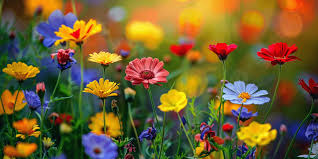

Gambar Hasil Steganografi BMP:


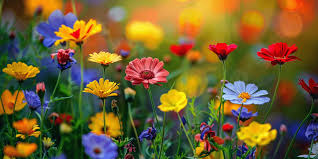

In [6]:
print("Gambar Asli BMP:")
display(Image.open("bunga.bmp"))

print("Gambar Hasil Steganografi BMP:")
display(Image.open("stego_bunga.bmp"))

In [8]:
files.download("stego_bunga.bmp")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>